In [1]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
df = pd.read_csv("final.csv")
#df


In [3]:
X = df['tweet_text']               # or df['tweets'] if you prefer the raw text
y = df['cyberbullying_type']


# 3. Split (stratify to preserve class proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% test, 80% train
    random_state=42,    # for reproducibility
    stratify=y          # keeps the same ratio of each type in both sets
)


In [4]:
#Linear SVM Classifier With TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10_000,
        ngram_range=(1,2),
        stop_words='english'
    )),
    ('svc', SVC(kernel='linear', probability=True))
])

from sklearn.svm import SVC

#svm_model = SVC(kernel='linear', C=1.0)
pipe.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('svc', SVC(kernel='linear', probability=True))])

In [5]:
y_pred = pipe.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.55      0.57      1563
           1       0.96      0.93      0.95      1600
           2       0.96      0.96      0.96      1598
           3       0.97      0.98      0.98      1592
           4       0.91      0.84      0.87      1588
           5       0.59      0.68      0.63      1520

    accuracy                           0.83      9461
   macro avg       0.83      0.82      0.83      9461
weighted avg       0.83      0.83      0.83      9461



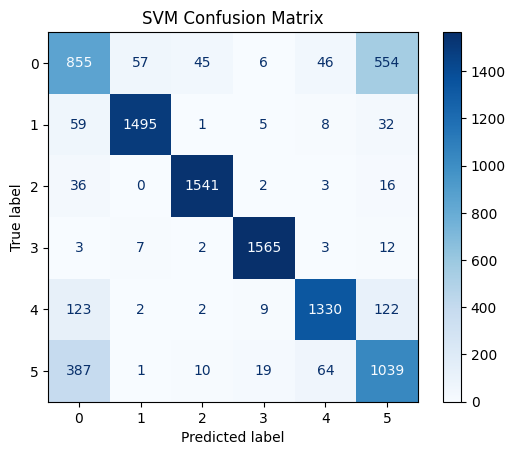

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)    # you can omit cmap if you don’t care about colors
plt.title("SVM Confusion Matrix")
plt.show()

# label_map = {
#     'not_cyberbullying': 0,
#     'religion': 1,
#     'age': 2,
#     'ethnicity': 3,
#     'gender': 4,
#     'other_cyberbullying': 5
# }

In [7]:
# Count Vectorizer Implementation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

count_pipe = Pipeline([
    ('count_vect', CountVectorizer(
        max_features=10_000,
        ngram_range=(1,2),
        stop_words='english'
    )),
    ('svc', SVC(kernel='linear', probability=True))
])

# Fit the pipeline
count_pipe.fit(X_train, y_train)

# Predict using the pipeline
y_pred_count = count_pipe.predict(X_test)

# Print classification report
print("Classification Report (Count Vectorizer):", classification_report(y_test, y_pred_count))

Classification Report (Count Vectorizer):               precision    recall  f1-score   support

           0       0.54      0.54      0.54      1563
           1       0.95      0.93      0.94      1600
           2       0.97      0.96      0.97      1598
           3       0.98      0.98      0.98      1592
           4       0.88      0.84      0.86      1588
           5       0.58      0.63      0.60      1520

    accuracy                           0.81      9461
   macro avg       0.82      0.81      0.81      9461
weighted avg       0.82      0.81      0.82      9461



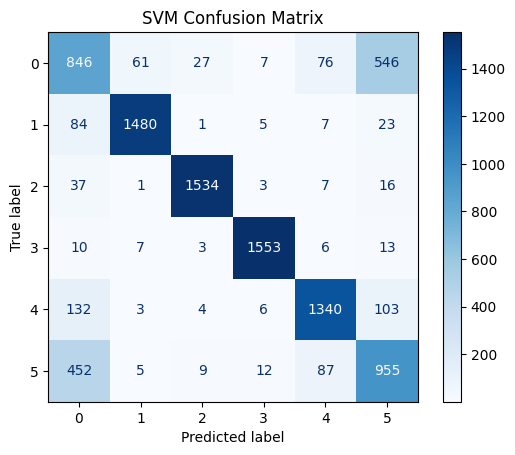

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm2 = confusion_matrix(y_test, y_pred_count)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)    # you can omit cmap if you don’t care about colors
plt.title("SVM Confusion Matrix")
plt.show()

# label_map = {
#     'not_cyberbullying': 0,
#     'religion': 1,
#     'age': 2,
#     'ethnicity': 3,
#     'gender': 4,
#     'other_cyberbullying': 5
# }